<style>
@page { size: A4; margin: 12mm; }
body { font-size: 8.5pt; line-height: 1.18; }
h1 { font-size: 19pt; margin: 0 0 7px 0; }
h2 { font-size: 13pt; margin: 5px 0; }
p { margin: 4px 0; }
.prompt, .input_prompt, .output_prompt { display:none !important; }
.input_area pre, .output_area pre { font-size: 6.4pt !important; line-height: 1.05 !important; white-space: pre-wrap !important; overflow-wrap: anywhere !important; }
div.output_area img { max-width: 96% !important; max-height: 245px !important; object-fit: contain; }
div.output_subarea { max-width: 100% !important; }
table { font-size: 7.5pt; }
</style>

# EN3160 Assignment 1 — Intensity Transformations and Neighborhood Filtering

**Student:** R.G.S.P. Kaushalya  
**Index:** 230327N   
**GitHub profile:** https://github.com/rgspkaushalya/EN3160_Assignment1

In [93]:
import os
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

def read_rgb(name):
    bgr = cv2.imread(str(IMG / name))
    if bgr is None:
        raise FileNotFoundError(f"Could not read {IMG / name}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def piecewise_transform(im, breakpoints):
    bp = np.asarray(breakpoints, dtype=float)
    return np.clip(
        np.rint(np.interp(im.astype(np.float32), bp[:, 0], bp[:, 1])),
        0, 255
    ).astype(np.uint8)

def intensity_transform(im, breakpoints):
    return piecewise_transform(im, breakpoints)

def hist_equalize_custom(im):
    hist = np.bincount(im.ravel(), minlength=256)
    cdf = np.cumsum(hist)
    nz = np.flatnonzero(hist)
    if len(nz) == 0:
        return im.copy(), hist, np.arange(256, dtype=np.uint8)
    cmin = cdf[nz[0]]
    denom = im.size - cmin
    if denom <= 0:
        lut = np.arange(256, dtype=np.uint8)
    else:
        lut = np.clip(np.round((cdf - cmin) * 255 / denom), 0, 255).astype(np.uint8)
    return lut[im], hist, lut

def zoom_nearest(im, s):
    if not (0 < s <= 10):
        raise ValueError("s must be in (0,10]")
    h, w = im.shape[:2]
    oh, ow = round(h * s), round(w * s)
    yy = np.clip(np.rint((np.arange(oh) + 0.5) / s - 0.5).astype(int), 0, h - 1)
    xx = np.clip(np.rint((np.arange(ow) + 0.5) / s - 0.5).astype(int), 0, w - 1)
    return im[yy[:, None], xx[None, :]]

def zoom_bilinear(im, s):
    if not (0 < s <= 10):
        raise ValueError("s must be in (0,10]")
    h, w = im.shape[:2]
    oh, ow = round(h * s), round(w * s)
    yy = (np.arange(oh) + 0.5) / s - 0.5;xx = (np.arange(ow) + 0.5) / s - 0.5
    y0 = np.clip(np.floor(yy).astype(int), 0, h - 1);x0 = np.clip(np.floor(xx).astype(int), 0, w - 1)
    y1 = np.clip(y0 + 1, 0, h - 1);x1 = np.clip(x0 + 1, 0, w - 1)
    wy = np.clip(yy - np.floor(yy), 0, 1).astype(np.float32)[:, None];wx = np.clip(xx - np.floor(xx), 0, 1).astype(np.float32)[None, :]
    if im.ndim == 3:
        wy = wy[:, :, None]
        wx = wx[:, :, None]
    a = im[y0[:, None], x0[None, :]].astype(np.float32);b = im[y0[:, None], x1[None, :]].astype(np.float32)
    c = im[y1[:, None], x0[None, :]].astype(np.float32);d = im[y1[:, None], x1[None, :]].astype(np.float32)
    out = (1-wy)*(1-wx)*a + (1-wy)*wx*b + wy*(1-wx)*c + wy*wx*d
    return np.clip(np.rint(out), 0, 255).astype(np.uint8)

def normalized_ssd(a, b):
    return np.mean((a.astype(np.float32) - b.astype(np.float32))**2) / (255.0**2)

def conv2_same(im, kernel):
    r = kernel.shape[0] // 2
    p = np.pad(im.astype(np.float32), ((r, r), (r, r)), mode='reflect')
    k = np.flipud(np.fliplr(kernel))
    out = np.zeros_like(im, dtype=np.float32)
    for i in range(im.shape[0]):
        for j in range(im.shape[1]):
            out[i, j] = np.sum(p[i:i+kernel.shape[0], j:j+kernel.shape[1]] * k)
    return out

def bilateral_custom(im, d=9, sigma_s=7, sigma_r=25):
    r = d // 2
    a_img = im.astype(np.float32)
    p = np.pad(a_img, ((r, r), (r, r), (0, 0)), mode='reflect')
    Y, X = np.mgrid[-r:r+1, -r:r+1]
    spatial = np.exp(-(X**2 + Y**2) / (2*sigma_s**2)).astype(np.float32)
    center = p[r:r+a_img.shape[0], r:r+a_img.shape[1]]
    num = np.zeros_like(a_img)
    den = np.zeros(a_img.shape[:2], np.float32)
    for dy in range(-r, r+1):
        for dx in range(-r, r+1):
            n = p[r+dy:r+dy+a_img.shape[0], r+dx:r+dx+a_img.shape[1]]
            dist2 = np.sum((n - center)**2, axis=2)
            w = np.exp(-dist2/(2*sigma_r**2)).astype(np.float32) * spatial[dy+r, dx+r]
            num += n * w[:, :, None]
            den += w
    return np.clip(num/(den[:, :, None] + 1e-8), 0, 255).astype(np.uint8)

# Q1
face = cv2.imread(str(IMG / "fig1.png"), cv2.IMREAD_GRAYSCALE)
bp1 = np.array([[0,0], [50,25], [120,205], [180,230], [255,255]])
face_out = intensity_transform(face, bp1)
# Q2
brain = cv2.imread(str(IMG / "fig2.png"), cv2.IMREAD_GRAYSCALE)
white_bp = np.array([[0,0], [150,0], [170,255], [185,255], [255,255]])
gray_bp = np.array([[0,0], [175,0], [195,255], [210,255], [255,255]])
white_out = intensity_transform(brain, white_bp)
gray_out = intensity_transform(brain, gray_bp)
# Q3
dress = read_rgb("fig3.png")
lab = cv2.cvtColor(dress, cv2.COLOR_RGB2LAB)
L = lab[:, :, 0]
gamma = 0.70
Lcorr = np.clip(255 * (L / 255.0) ** gamma, 0, 255).astype(np.uint8)
lab2 = lab.copy()
lab2[:, :, 0] = Lcorr
dress_corr = cv2.cvtColor(lab2, cv2.COLOR_LAB2RGB)
# Q4
spider = read_rgb("fig4.png")
hsv = cv2.cvtColor(spider, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(hsv)
a = 0.65
sigma = 70
S2 = np.clip(
    S.astype(np.float32) + a*128*np.exp(-((S.astype(np.float32)-128)**2)/(2*sigma**2)),
    0, 255
).astype(np.uint8)
vibrance = cv2.cvtColor(cv2.merge([H, S2, V]), cv2.COLOR_HSV2RGB)
# Q5
beans = cv2.imread(str(IMG / "fig5.png"), cv2.IMREAD_GRAYSCALE)
beans_eq, hist_before, _ = hist_equalize_custom(beans)
hist_after = np.bincount(beans_eq.ravel(), minlength=256)
# Q6
woman = read_rgb("fig6.png")
hsvw = cv2.cvtColor(woman, cv2.COLOR_RGB2HSV)
H, S, V = cv2.split(hsvw)
mask = ((S > 20) | (V < 70)).astype(np.uint8) * 255
k = np.ones((7,7), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5,5), np.uint8))
fg = cv2.bitwise_and(V, V, mask=mask)
fg_values = fg[mask > 0]
hist_fg = np.bincount(fg_values.ravel(), minlength=256)
cdf = np.cumsum(hist_fg)
nz = np.flatnonzero(hist_fg)
if len(nz):
    cmin = cdf[nz[0]]
    denom = len(fg_values) - cmin
    lut = np.clip(np.round((cdf-cmin)*255/denom), 0, 255).astype(np.uint8) if denom > 0 else np.arange(256, dtype=np.uint8)
else:
    lut = np.arange(256, dtype=np.uint8)
Veq = V.copy()
Veq[mask > 0] = lut[V[mask > 0]]
foreground_eq = cv2.cvtColor(cv2.merge([H, S, Veq]), cv2.COLOR_HSV2RGB)
# Q7
ein = cv2.imread(str(IMG / "fig7.png"), cv2.IMREAD_GRAYSCALE)
kx = np.array([[1,0,-1], [2,0,-2], [1,0,-1]], np.float32)
ky = kx.T
gx = cv2.filter2D(ein, cv2.CV_32F, kx)
gy = cv2.filter2D(ein, cv2.CV_32F, ky)
sobel_cv = cv2.normalize(np.sqrt(gx*gx + gy*gy), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gx2 = conv2_same(ein, kx)
gy2 = conv2_same(ein, ky)
sobel_own = cv2.normalize(np.sqrt(gx2*gx2 + gy2*gy2), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
smooth = np.array([[1],[2],[1]], np.float32)
deriv = np.array([[1,0,-1]], np.float32)
gx3 = cv2.filter2D(cv2.filter2D(ein, cv2.CV_32F, smooth), cv2.CV_32F, deriv)
gy3 = cv2.filter2D(cv2.filter2D(ein, cv2.CV_32F, deriv.T), cv2.CV_32F, smooth.T)
sobel_sep = cv2.normalize(np.sqrt(gx3*gx3 + gy3*gy3), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
# Q8
def read_gray_q8(name):
    path = IMG / name
    im = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if im is None:
        raise FileNotFoundError(f"Could not read image: {path}")
    return im
im01_original = read_gray_q8("im01.png");im01_small = read_gray_q8("im01small.png")
im02_original = read_gray_q8("im02.png");im02_small = read_gray_q8("im02small.png")
im03_original = read_gray_q8("im03.png");im03_small = read_gray_q8("im03small.png")
im04_original = read_gray_q8("im04.jpg");im04_small = read_gray_q8("im04small.jpg")
scale = 4
images = [("IM01", im01_small, im01_original),
    ("IM02", im02_small, im02_original),
    ("IM03", im03_small, im03_original),
    ("IM04", im04_small, im04_original)]
# Q9
flower = cv2.imread(str(IMG / "fig8.png"))
h, w = flower.shape[:2]
gc = np.zeros((h,w), np.uint8)
bgd = np.zeros((1,65), np.float64)
fgd = np.zeros((1,65), np.float64)
cv2.grabCut(flower, gc, (10,10,w-20,h-20), bgd, fgd, 5, cv2.GC_INIT_WITH_RECT)
fgmask = np.where((gc == cv2.GC_FGD) | (gc == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
blur = cv2.GaussianBlur(flower, (0,0), 12)
enh = np.where(fgmask[:,:,None] == 1, flower, blur).astype(np.uint8)
# Q10
lake = cv2.imread(str(IMG / "fig9.png"))
gaussian = cv2.GaussianBlur(lake, (9,9), 7)
bilateral_cv = cv2.bilateralFilter(lake, 9, 25, 7)
bilateral_own = bilateral_custom(lake, 9, 7, 25)
mse = np.mean((bilateral_cv.astype(np.float32) - bilateral_own.astype(np.float32))**2)
psnr = 10*np.log10(255**2/mse) if mse > 0 else float('inf')
mae = np.mean(np.abs(bilateral_cv.astype(np.float32) - bilateral_own.astype(np.float32)))

print("Setup complete: Q1-Q10 variables loaded successfully.")

Setup complete: Q1-Q10 variables loaded successfully.


## 1. Piecewise intensity transformation

A piecewise-linear mapping is implemented by `intensity_transform(im, breakpoints)`. I used the breakpoints
`[(0,0), (50,25), (120,205), (180,230), (255,255)]`, which increase contrast in the middle intensity range while keeping the endpoints fixed.

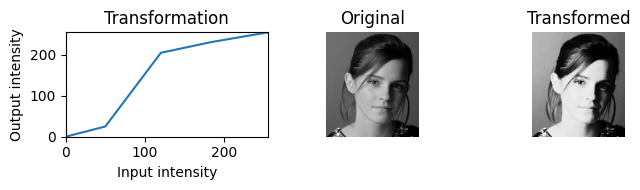

In [65]:
x=np.arange(256)
y=np.interp(x,bp1[:,0],bp1[:,1])
fig,ax=plt.subplots(1,3,figsize=(7,2))
ax[0].plot(x,y); ax[0].set(xlim=(0,255),ylim=(0,255),xlabel='Input intensity',ylabel='Output intensity',title='Transformation')
ax[1].imshow(face,cmap='gray',vmin=0,vmax=255); ax[1].axis('off'); ax[1].set_title('Original')
ax[2].imshow(face_out,cmap='gray',vmin=0,vmax=255); ax[2].axis('off'); ax[2].set_title('Transformed')
plt.tight_layout(); plt.show()

## 2. Accentuation of white and gray matter

Two different piecewise mappings were selected so that the intensity interval associated with each tissue type is expanded to a high output range. The selected mappings are shown in the plots below.

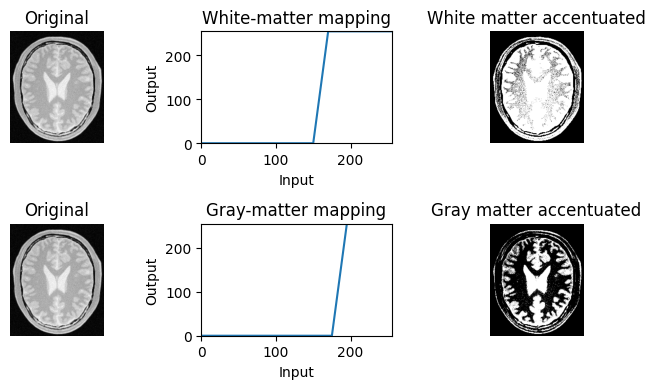

In [66]:
x=np.arange(256)
yw=np.interp(x,white_bp[:,0],white_bp[:,1]); yg=np.interp(x,gray_bp[:,0],gray_bp[:,1])
fig,ax=plt.subplots(2,3,figsize=(7,4))
ax[0,0].imshow(brain,cmap='gray'); ax[0,0].axis('off'); ax[0,0].set_title('Original')
ax[0,1].plot(x,yw); ax[0,1].set(xlim=(0,255),ylim=(0,255),title='White-matter mapping',xlabel='Input',ylabel='Output')
ax[0,2].imshow(white_out,cmap='gray'); ax[0,2].axis('off'); ax[0,2].set_title('White matter accentuated')
ax[1,0].imshow(brain,cmap='gray'); ax[1,0].axis('off'); ax[1,0].set_title('Original')
ax[1,1].plot(x,yg); ax[1,1].set(xlim=(0,255),ylim=(0,255),title='Gray-matter mapping',xlabel='Input',ylabel='Output')
ax[1,2].imshow(gray_out,cmap='gray'); ax[1,2].axis('off'); ax[1,2].set_title('Gray matter accentuated')
plt.tight_layout(); plt.show()

## 3. Gamma correction in L*a*b*

Gamma correction was applied only to the **L*** plane. I selected **γ = 0.70** so that the darker parts of the image are expanded while chromatic information in a* and b* is retained.

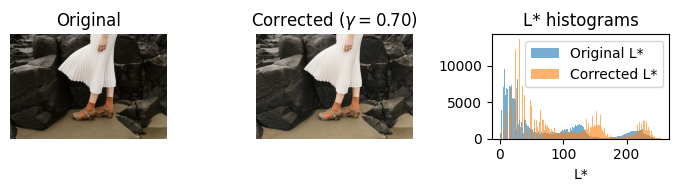

In [79]:
fig,ax=plt.subplots(1,3,figsize=(7,2))
ax[0].imshow(dress); ax[0].axis('off'); ax[0].set_title('Original')
ax[1].imshow(dress_corr); ax[1].axis('off'); ax[1].set_title(r'Corrected ($\gamma=0.70$)')
ax[2].hist(L.ravel(),bins=256,range=(0,255),alpha=.6,label='Original L*')
ax[2].hist(Lcorr.ravel(),bins=256,range=(0,255),alpha=.6,label='Corrected L*')
ax[2].set_title('L* histograms'); ax[2].set_xlabel('L*'); ax[2].legend()
plt.tight_layout(); plt.show()

## 4. Vibrance enhancement

The saturation mapping from the question was applied with **a = 0.65** and σ = 70. This gives a stronger increase around mid-range saturation while limiting clipping at 255.

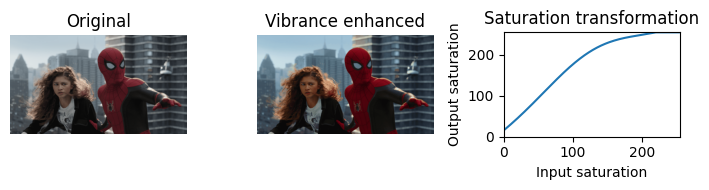

In [68]:
s=np.arange(256)
sf=np.minimum(s+a*128*np.exp(-((s-128)**2)/(2*sigma**2)),255)
fig,ax=plt.subplots(1,3,figsize=(7,2))
ax[0].imshow(spider); ax[0].axis('off'); ax[0].set_title('Original')
ax[1].imshow(vibrance); ax[1].axis('off'); ax[1].set_title('Vibrance enhanced')
ax[2].plot(s,sf); ax[2].set(xlim=(0,255),ylim=(0,255),xlabel='Input saturation',ylabel='Output saturation',title='Saturation transformation')
plt.tight_layout(); plt.show()

## 5. Histogram equalization

A histogram equalization function was written from scratch. The cumulative histogram is normalized using the first non-zero CDF value and used as a 256-entry lookup table.

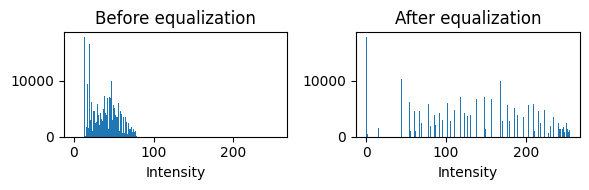

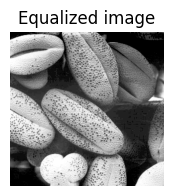

In [69]:
fig,ax=plt.subplots(1,2,figsize=(6,2))
ax[0].hist(beans.ravel(),bins=256,range=(0,255)); ax[0].set_title('Before equalization'); ax[0].set_xlabel('Intensity')
ax[1].hist(beans_eq.ravel(),bins=256,range=(0,255)); ax[1].set_title('After equalization'); ax[1].set_xlabel('Intensity')
plt.tight_layout()
plt.figure(figsize=(3,2)); plt.imshow(beans_eq,cmap='gray'); plt.axis('off'); plt.title('Equalized image'); plt.show()

## 6. Histogram equalization of the foreground

The HSV planes were inspected and a mask was formed mainly from saturation, with a low-value condition to include dark parts of the subject. The foreground value histogram was then equalized using a CDF lookup table, while the background was retained unchanged.

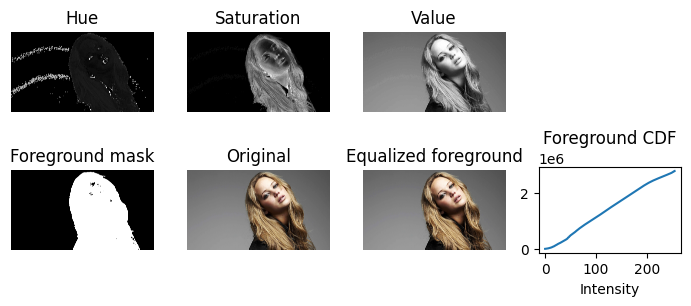

In [102]:
fig,ax=plt.subplots(2,4,figsize=(7,3))
for a0,im,t in zip(ax[0,:3],[H,S,V],['Hue','Saturation','Value']):
    a0.imshow(im,cmap='gray'); a0.axis('off'); a0.set_title(t)
ax[0,3].axis('off')
ax[1,0].imshow(mask,cmap='gray'); ax[1,0].axis('off'); ax[1,0].set_title('Foreground mask')
ax[1,1].imshow(woman); ax[1,1].axis('off'); ax[1,1].set_title('Original')
ax[1,2].imshow(foreground_eq); ax[1,2].axis('off'); ax[1,2].set_title('Equalized foreground')
ax[1,3].plot(np.cumsum(hist_fg)); ax[1,3].set_title('Foreground CDF'); ax[1,3].set_xlabel('Intensity')
plt.tight_layout(); plt.show()

## 7. Sobel filtering

Three implementations were compared: OpenCV `filter2D`, an explicit 3×3 convolution, and the separable Sobel property
Gx = [1,2,1]^T * [1,0,-1]. The explicit implementation uses reflected padding and direct convolution.

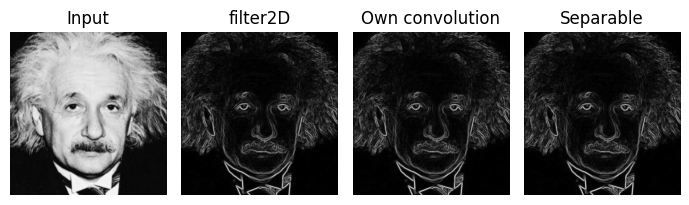

Mean absolute difference: own vs filter2D = 0.0


In [100]:
fig,ax=plt.subplots(1,4,figsize=(7,2))
ax[0].imshow(ein,cmap='gray'); ax[0].axis('off'); ax[0].set_title('Input')
for a0,im,t in zip(ax[1:], [sobel_cv,sobel_own,sobel_sep], ['filter2D','Own convolution','Separable']):
    a0.imshow(im,cmap='gray'); a0.axis('off'); a0.set_title(t)
plt.tight_layout(); plt.show()
print('Mean absolute difference: own vs filter2D =',np.mean(np.abs(sobel_own.astype(float)-sobel_cv.astype(float))))

## 8. Image zooming

The required functions support any scale **s ∈ (0,10]** and implement nearest-neighbor and bilinear interpolation without calling an image-resize function for the interpolation itself.

IM01 , Original size : (1080, 1920) , Small size    : (270, 480) , Zoomed size   : (1080, 1920) , Nearest NSSD  : 0.002110 , Bilinear NSSD : 0.001785


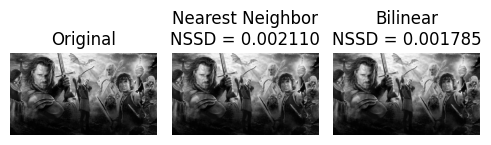

IM02 , Original size : (1200, 1920) , Small size    : (300, 480) , Zoomed size   : (1200, 1920) , Nearest NSSD  : 0.000410 , Bilinear NSSD : 0.000284


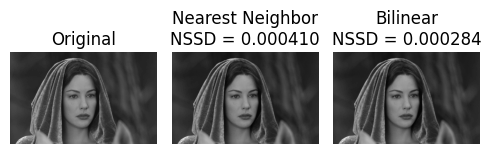

IM03 , Original size : (1459, 2400) , Small size    : (365, 600) , Zoomed size   : (1459, 2400) , Nearest NSSD  : 0.001027 , Bilinear NSSD : 0.000779


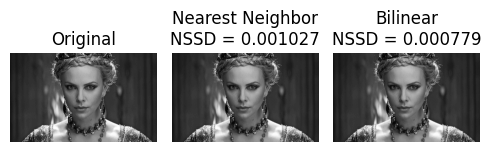

IM04 , Original size : (112, 200) , Small size    : (28, 50) , Zoomed size   : (112, 200) , Nearest NSSD  : 0.003382 , Bilinear NSSD : 0.002973


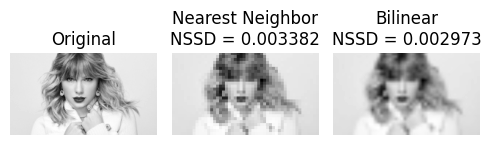

In [89]:
for name, small, original in images:
    nn = zoom_nearest(small, scale)
    bl = zoom_bilinear(small, scale)
    H, W = original.shape[:2]
    nn = nn[:H, :W]
    bl = bl[:H, :W]
    nn_ssd = normalized_ssd(nn, original)
    bl_ssd = normalized_ssd(bl, original)
    print(f"{name} , Original size : {original.shape} , Small size    : {small.shape} , Zoomed size   : {nn.shape} , Nearest NSSD  : {nn_ssd:.6f} , Bilinear NSSD : {bl_ssd:.6f}")
    fig, ax = plt.subplots(1, 3, figsize=(5, 2));ax[0].imshow(original, cmap="gray");ax[0].set_title("Original");ax[0].axis("off")
    ax[1].imshow(nn, cmap="gray");ax[1].set_title(f"Nearest Neighbor\nNSSD = {nn_ssd:.6f}");ax[1].axis("off")
    ax[2].imshow(bl, cmap="gray");ax[2].set_title(f"Bilinear\nNSSD = {bl_ssd:.6f}");ax[2].axis("off")
    plt.tight_layout();plt.show()

<div style="display:block; height:1px; page-break-after: always; break-after: page;"></div>

## 9. GrabCut and background enhancement

GrabCut was initialized with a rectangle around the flower. The segmented foreground was retained, while the background was strongly Gaussian-blurred (σ = 12).

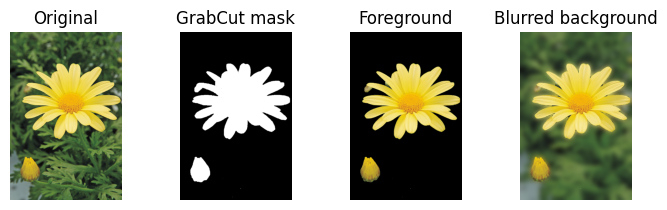

In [104]:
fig,ax=plt.subplots(1,4,figsize=(7,2.2))
ax[0].imshow(cv2.cvtColor(flower,cv2.COLOR_BGR2RGB)); ax[0].axis('off'); ax[0].set_title('Original')
ax[1].imshow(fgmask,cmap='gray'); ax[1].axis('off'); ax[1].set_title('GrabCut mask')
ax[2].imshow(cv2.cvtColor(cv2.bitwise_and(flower,flower,mask=fgmask),cv2.COLOR_BGR2RGB)); ax[2].axis('off'); ax[2].set_title('Foreground')
ax[3].imshow(cv2.cvtColor(enh,cv2.COLOR_BGR2RGB)); ax[3].axis('off'); ax[3].set_title('Blurred background')
plt.tight_layout(); plt.show()

**(c)** A dark halo can appear just outside the flower if the background is first isolated with a zero-valued mask and then blurred. The Gaussian kernel averages those zero pixels into nearby background pixels, lowering their intensity. Blurring the complete image first and compositing afterward avoids this artificial darkening.

## 10. Bilateral filtering

OpenCV's bilateral filter was used with **d = 9, σs = 7, σr = 25**. A custom bilateral filter was then implemented using a spatial Gaussian multiplied by a range Gaussian based on RGB distance.

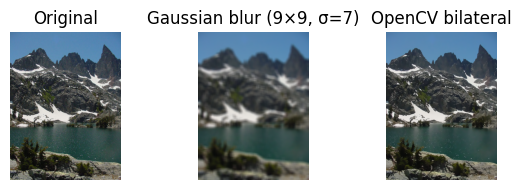

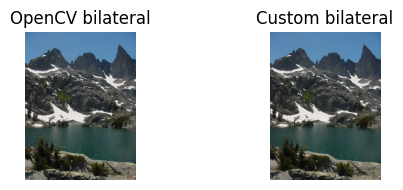

MAE = 1.758, MSE = 7.201, PSNR = 39.56 dB


In [99]:
fig,ax=plt.subplots(1,3,figsize=(6,2))
for a0,im,t in zip(ax,[lake,gaussian,bilateral_cv],['Original','Gaussian blur (9×9, σ=7)','OpenCV bilateral']):
    a0.imshow(cv2.cvtColor(im,cv2.COLOR_BGR2RGB)); a0.axis('off'); a0.set_title(t)
plt.tight_layout(); plt.show()
fig,ax=plt.subplots(1,2,figsize=(6,2))
ax[0].imshow(cv2.cvtColor(bilateral_cv,cv2.COLOR_BGR2RGB)); ax[0].axis('off'); ax[0].set_title('OpenCV bilateral')
ax[1].imshow(cv2.cvtColor(bilateral_own,cv2.COLOR_BGR2RGB)); ax[1].axis('off'); ax[1].set_title('Custom bilateral')
plt.tight_layout(); plt.show()
print(f'MAE = {mae:.3f}, MSE = {mse:.3f}, PSNR = {psnr:.2f} dB')

**Discussion:** The Gaussian filter reduces noise but also smooths strong edges. The bilateral filter uses both spatial distance and intensity similarity, so pixels across a strong edge receive much smaller weights. The custom implementation is close to OpenCV's result (PSNR ≈ 39.56 dB), confirming that the main bilateral-filter mechanism was implemented correctly.